In [1]:
# ============================================================
# BLOQUE 1: Importacion de librerias
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerias importadas correctamente")
print(f"   shap version: {shap.__version__}")

Librerias importadas correctamente
   shap version: 0.51.0


In [2]:
# ============================================================
# BLOQUE 2: Carga de datos y modelos
# ============================================================

# Datos procesados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Modelos entrenados
rf_model  = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

# Resultados previos
resultados = joblib.load('../models/resultados_modelos.pkl')
umbral_opt_rf  = resultados['umbral_opt_rf']
umbral_opt_xgb = resultados['umbral_opt_xgb']

print("Datos y modelos cargados correctamente")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Umbral optimo RF  : {umbral_opt_rf:.4f}")
print(f"Umbral optimo XGB : {umbral_opt_xgb:.4f}")


Datos y modelos cargados correctamente
X_train : (60000, 170)
X_test  : (16000, 170)
Umbral optimo RF  : 0.0248
Umbral optimo XGB : 0.0100


In [4]:
# ============================================================
# BLOQUE 3: Calculo de valores SHAP
# ============================================================

np.random.seed(42)
muestra_idx    = np.random.choice(X_test.shape[0], size=2000, replace=False)
X_test_muestra = X_test.iloc[muestra_idx].reset_index(drop=True)

print("Calculando SHAP values para Random Forest...")
explainer_rf   = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_muestra, check_additivity=False)

# TreeExplainer devuelve lista [clase_0, clase_1] para clasificacion binaria
# Nos quedamos con la clase positiva (falla APS)
if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[1]

print("Random Forest completado.")

print("\nCalculando SHAP values para XGBoost...")
explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_muestra, check_additivity=False)

if isinstance(shap_values_xgb, list):
    shap_values_xgb = shap_values_xgb[1]

print("XGBoost completado.")

print(f"\nShape SHAP values RF  : {shap_values_rf.shape}")
print(f"Shape SHAP values XGB : {shap_values_xgb.shape}")

Calculando SHAP values para Random Forest...
Random Forest completado.

Calculando SHAP values para XGBoost...
XGBoost completado.

Shape SHAP values RF  : (2000, 170, 2)
Shape SHAP values XGB : (2000, 170)


In [5]:
# ============================================================
# BLOQUE 4: Normalizacion de shapes SHAP
# ============================================================

# Random Forest devuelve (n_samples, n_features, n_classes)
# Nos quedamos con la clase positiva (indice 1)
if shap_values_rf.ndim == 3:
    shap_values_rf = shap_values_rf[:, :, 1]

print(f"Shape SHAP values RF  (normalizado): {shap_values_rf.shape}")
print(f"Shape SHAP values XGB (normalizado): {shap_values_xgb.shape}")

# Calcular importancia media absoluta por variable
importancia_rf  = pd.Series(
    np.abs(shap_values_rf).mean(axis=0),
    index=X_test_muestra.columns
).sort_values(ascending=False)

importancia_xgb = pd.Series(
    np.abs(shap_values_xgb).mean(axis=0),
    index=X_test_muestra.columns
).sort_values(ascending=False)

print("\nTop 10 variables mas importantes - Random Forest:")
print(importancia_rf.head(10).to_string())

print("\nTop 10 variables mas importantes - XGBoost:")
print(importancia_xgb.head(10).to_string())

Shape SHAP values RF  (normalizado): (2000, 170)
Shape SHAP values XGB (normalizado): (2000, 170)

Top 10 variables mas importantes - Random Forest:
aa_000   0.0234
ci_000   0.0231
bj_000   0.0210
dn_000   0.0191
ck_000   0.0177
aq_000   0.0171
bt_000   0.0142
bu_000   0.0114
cs_002   0.0113
ap_000   0.0108

Top 10 variables mas importantes - XGBoost:
aa_000   1.9434
ck_000   1.3476
ci_000   0.8990
bs_000   0.5928
ay_008   0.3998
cb_000   0.3796
bk_000   0.2959
ai_000   0.2936
cn_003   0.2602
aq_000   0.2590


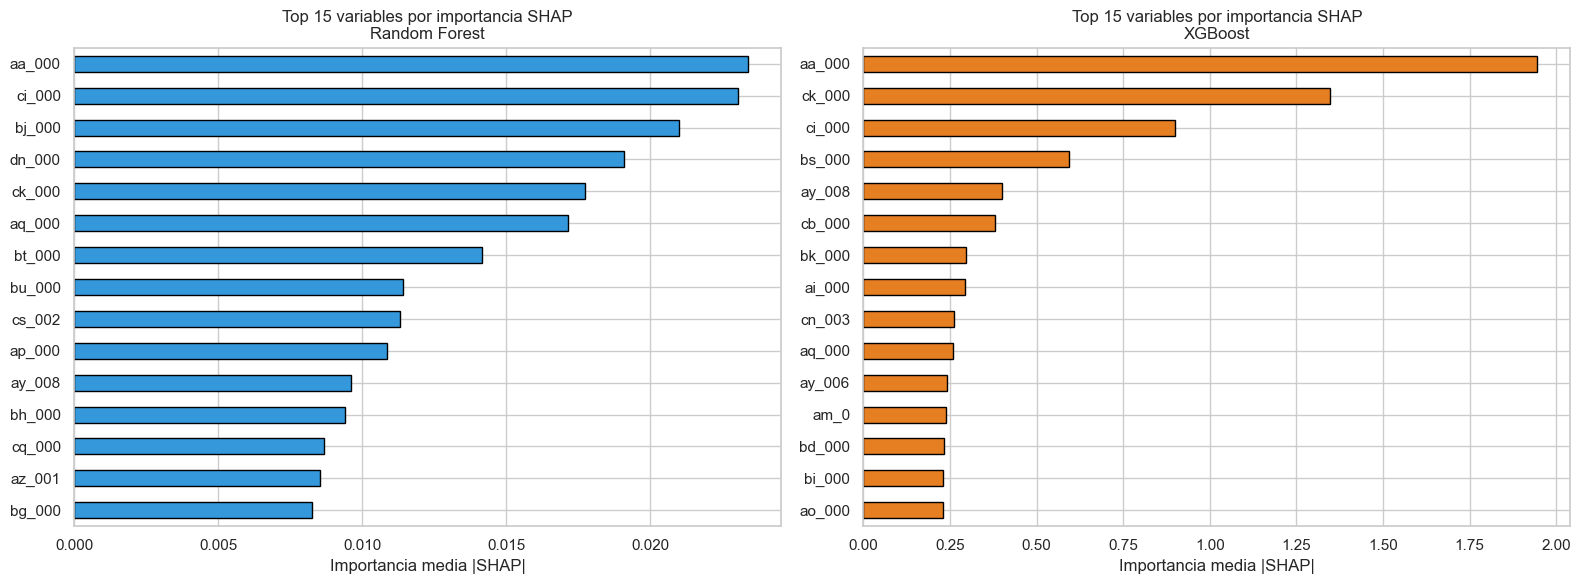

Grafico guardado en outputs/


In [6]:
# ============================================================
# BLOQUE 5: Grafico de importancia global (Bar plot)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_n = 15

# Random Forest
importancia_rf.head(top_n).sort_values().plot(
    kind='barh', ax=axes[0], color='#3498db', edgecolor='black'
)
axes[0].set_title(f'Top {top_n} variables por importancia SHAP\nRandom Forest', fontsize=12)
axes[0].set_xlabel('Importancia media |SHAP|')

# XGBoost
importancia_xgb.head(top_n).sort_values().plot(
    kind='barh', ax=axes[1], color='#e67e22', edgecolor='black'
)
axes[1].set_title(f'Top {top_n} variables por importancia SHAP\nXGBoost', fontsize=12)
axes[1].set_xlabel('Importancia media |SHAP|')

plt.tight_layout()
plt.savefig('../outputs/06_shap_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

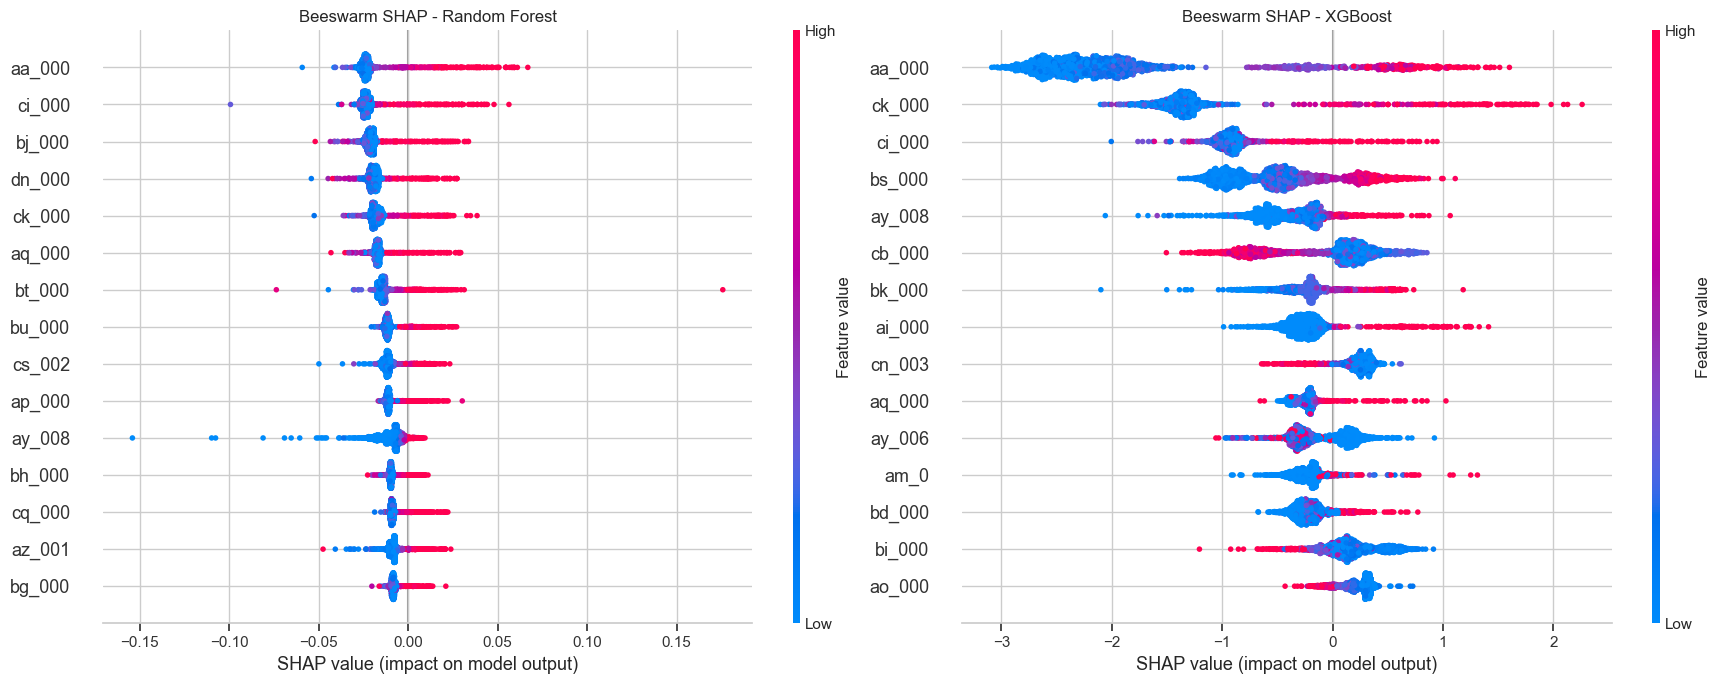

Grafico guardado en outputs/


In [7]:
# ============================================================
# BLOQUE 6: Beeswarm plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values_rf,
    X_test_muestra,
    max_display=15,
    show=False,
    plot_size=None
)
axes[0].set_title('Beeswarm SHAP - Random Forest', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_values_xgb,
    X_test_muestra,
    max_display=15,
    show=False,
    plot_size=None
)
axes[1].set_title('Beeswarm SHAP - XGBoost', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/07_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

Casos positivos en la muestra: 39
Caso analizado: indice 37


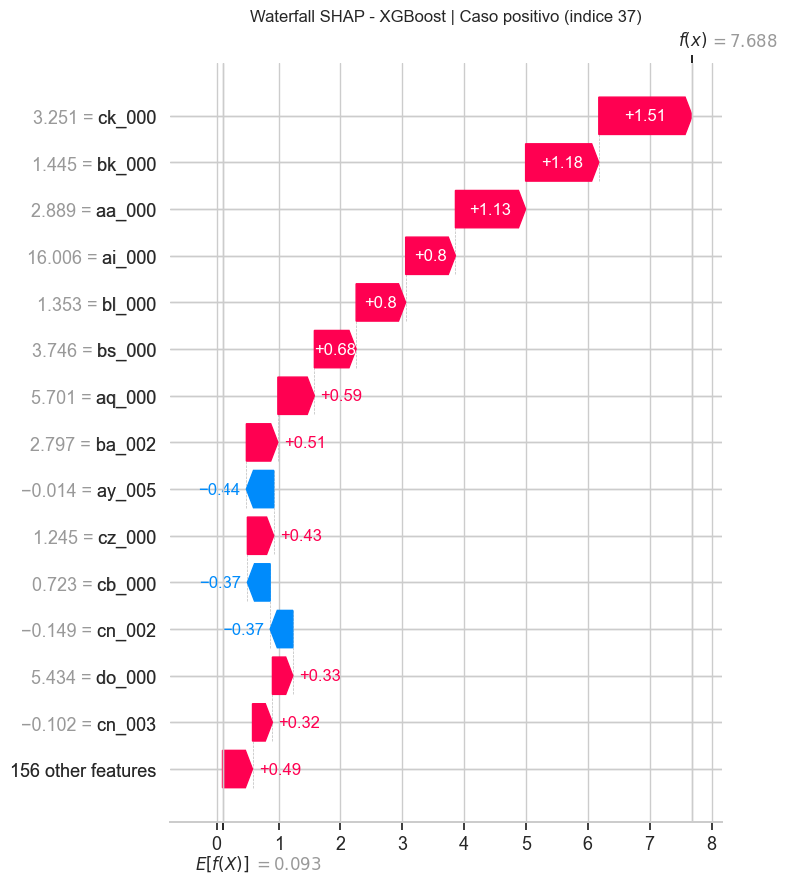

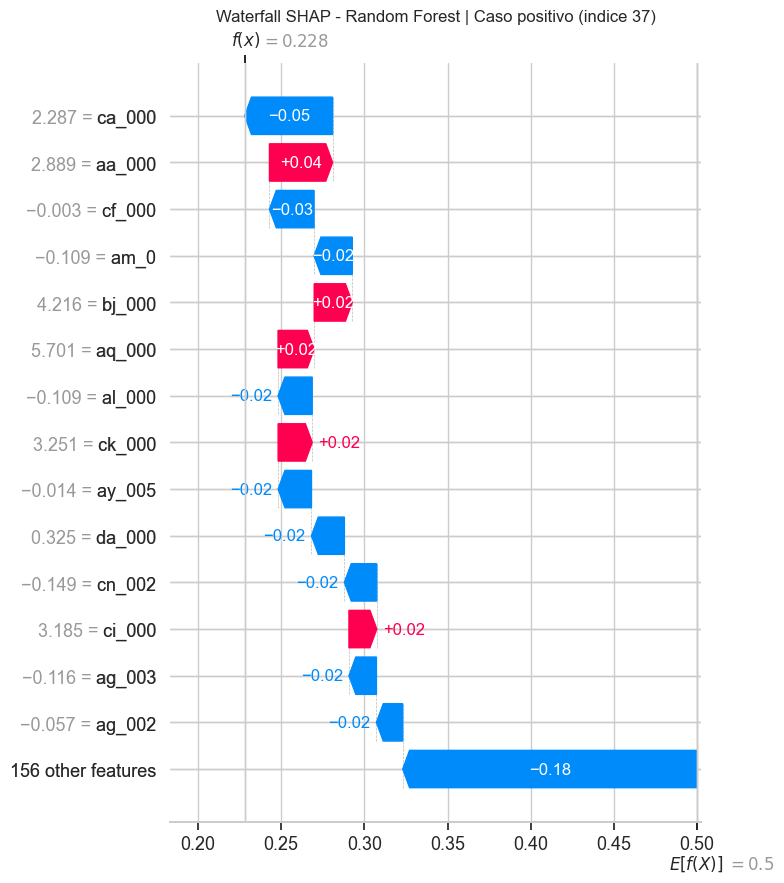

Graficos guardados en outputs/


In [8]:
# ============================================================
# BLOQUE 7: Waterfall plot - explicacion individual
# ============================================================

# Se selecciona un caso positivo real (falla APS confirmada)
y_test_muestra = y_test.iloc[muestra_idx].reset_index(drop=True)
indices_positivos = y_test_muestra[y_test_muestra == 1].index.tolist()

print(f"Casos positivos en la muestra: {len(indices_positivos)}")

# Se toma el primer caso positivo
caso_idx = indices_positivos[0]
print(f"Caso analizado: indice {caso_idx}")

# --- Waterfall XGBoost ---
explicacion_xgb = shap.Explanation(
    values        = shap_values_xgb[caso_idx],
    base_values   = explainer_xgb.expected_value,
    data          = X_test_muestra.iloc[caso_idx].values,
    feature_names = X_test_muestra.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explicacion_xgb, max_display=15, show=False)
plt.title(f'Waterfall SHAP - XGBoost | Caso positivo (indice {caso_idx})', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/08_shap_waterfall_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Waterfall Random Forest ---
explicacion_rf = shap.Explanation(
    values        = shap_values_rf[caso_idx],
    base_values   = explainer_rf.expected_value[1],
    data          = X_test_muestra.iloc[caso_idx].values,
    feature_names = X_test_muestra.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explicacion_rf, max_display=15, show=False)
plt.title(f'Waterfall SHAP - Random Forest | Caso positivo (indice {caso_idx})', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/08_shap_waterfall_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graficos guardados en outputs/")

In [9]:
# ============================================================
# BLOQUE 8: Guardado de valores SHAP
# ============================================================

import os
os.makedirs('../models', exist_ok=True)

shap_data = {
    'shap_values_rf'   : shap_values_rf,
    'shap_values_xgb'  : shap_values_xgb,
    'X_test_muestra'   : X_test_muestra,
    'y_test_muestra'   : y_test_muestra,
    'muestra_idx'      : muestra_idx,
    'importancia_rf'   : importancia_rf,
    'importancia_xgb'  : importancia_xgb,
    'expected_value_rf' : explainer_rf.expected_value,
    'expected_value_xgb': explainer_xgb.expected_value,
}

joblib.dump(shap_data, '../models/shap_data.pkl')

print("Valores SHAP guardados en models/shap_data.pkl")
print(f"   shap_values_rf  : {shap_values_rf.shape}")
print(f"   shap_values_xgb : {shap_values_xgb.shape}")
print(f"   X_test_muestra  : {X_test_muestra.shape}")
print(f"   Casos positivos : {(y_test_muestra == 1).sum()}")

Valores SHAP guardados en models/shap_data.pkl
   shap_values_rf  : (2000, 170)
   shap_values_xgb : (2000, 170)
   X_test_muestra  : (2000, 170)
   Casos positivos : 39
